![Logo Javeriana](https://images.seeklogo.com/logo-png/11/1/pontificia-universidad-javeriana-logo-png_seeklogo-110703.png)

## Nombres: 
- Gabriel Jaramillo Cuberos (Id: 20529022)
- Samuel Beltrán Martínez (Id: 20524509)
- David Vargas (Id: 20485686)
- Juan Felipe Gómez López (Id: 20553416)
- Sara Pulgarín (Id: 20491129)
- Juan Camilo Delgado (Id: 20506996)

### Primera entrega del proyecto

*Materia:* Procesamiento de Datos (1255)

*Tema:* Consultoría Nueva York.

*Descripción:* En este cuaderno se trabaja con los datos de arrestos.

*Nombre del fichero:* 01_Arrestos.ipynb

# Cuaderno 1 - Arrestos: descripción, calidad y preparación

**Primera entrega: Entendimiento del negocio y de los datos**

**Año objetivo: 2018**

El equipo actúa como consultor para elaborar un diagnóstico histórico de la ciudad de **Nueva York**.
El objetivo es describir arrestos, siniestros y condiciones socioeconómicas, preparar indicadores comparables
y documentar limitaciones para una futura priorización. La primera entrega no presenta respuestas definitivas
a las ocho preguntas ni un plan de intervención cerrado.

Los CSV, ubicados en la carpeta de datasets del clúster, se leen con una función compartida del archivo *proyecto.py*. Se ejecuta Spark en el cluster del taller, con un máximo de dos núcleos por aplicación (esto se hace para no ocupar todos los recursos del clúster).

In [1]:
# Comprobar kernel

import sys
import pyspark

print("Python:", sys.version)
print("Ejecutable:", sys.executable)
print("PySpark:", pyspark.__version__)

Python: 3.11.13 (main, Jun  1 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-14)]
Ejecutable: /home/estudiante/jupyter-spark-env/bin/python
PySpark: 4.2.0


## 1. Configuración del cluster

La configuración compartida reproduce los recursos y el Python del taller.

In [1]:
# Se inicia la sesión spark.

from Utils import proyecto as p
from Utils.proyecto import ANIO, DATA_DIR, RESULTADOS
spark = p.iniciar_spark("Entrega1_Arrestos")
from pyspark.sql import functions as F
from IPython.display import display, Markdown
print("Directorio de entrada:", DATA_DIR) # Imprime el directorio de donde llegan los datos.
print("Directorio de resultados:", RESULTADOS) # Imprime el directorio a donde van los resultados.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Python: 3.11.13 | PySpark: 4.2.0 | Spark: 4.2.0
Ejecutable: /home/estudiante/jupyter-spark-env/bin/python
Aplicación: app-20260921201100-0021 | Máximo de núcleos: 2
Los recursos físicos del cluster deben documentarse desde la interfaz del master.
Directorio de entrada: /opt/cluster/Proyecto/Entrega_1/datasets
Directorio de resultados: /opt/cluster/Proyecto/Entrega_1/resultados


## 2. Fuente y alcance

Entrada: **`Arrestos_NY.csv`**. Una fila representa un arresto; `ARREST_KEY` es la clave del evento.
Fuente de los datos: [NYPD Arrest Data Year to Date](https://data.cityofnewyork.us/Public-Safety/NYPD-Arrest-Data-Year-to-Date-/uip8-fykc).
El código verificará la cobertura. Si no existen registros de 2018, guardará
un resumen vacío con estado *sin_datos_2018*, y continuará con el reporte de calidad y las limitaciones.

In [2]:
# Se obtienen los datos en crudo del CSV. Usando el JSON de diccionarios, muestra la descripción de cada uno de los atributos.

df_crudo = p.leer_csv(spark, 
                      "Arrestos_NY.csv", 
                      [
                          "arrest_key", 
                          "arrest_date", 
                          "arrest_boro", 
                          "law_cat_cd", 
                          "age_group"
                      ]
                     )

df_crudo.printSchema()
p.diccionario(df_crudo, "arrestos")

root
 |-- arrest_key: string (nullable = true)
 |-- arrest_date: string (nullable = true)
 |-- pd_cd: string (nullable = true)
 |-- pd_desc: string (nullable = true)
 |-- ky_cd: string (nullable = true)
 |-- ofns_desc: string (nullable = true)
 |-- law_code: string (nullable = true)
 |-- law_cat_cd: string (nullable = true)
 |-- arrest_boro: string (nullable = true)
 |-- arrest_precinct: string (nullable = true)
 |-- jurisdiction_code: string (nullable = true)
 |-- age_group: string (nullable = true)
 |-- perp_sex: string (nullable = true)
 |-- perp_race: string (nullable = true)
 |-- x_coord_cd: string (nullable = true)
 |-- y_coord_cd: string (nullable = true)
 |-- latitude: string (nullable = true)
 |-- longitude: string (nullable = true)
 |-- lon_lat: string (nullable = true)



atributo,tipo_leido,significado,codigos_notas
arrest_key,string (CSV original),Randomly generated persistent ID for each arrest,
arrest_date,string (CSV original),Exact date of arrest for the reported event,
pd_cd,string (CSV original),Three digit internal classification code (more granular than Key Code),
pd_desc,string (CSV original),Description of internal classification corresponding with PD code (more granular than Offense Description),
ky_cd,string (CSV original),Three digit internal classification code (more general category than PD code),
ofns_desc,string (CSV original),Description of internal classification corresponding with KY code (more general category than PD description),
law_code,string (CSV original),"Law code charges corresponding to the NYS Penal Law, VTL and other various local laws",
law_cat_cd,string (CSV original),"Level of offense: felony, misdemeanor, violation",
arrest_boro,string (CSV original),"Borough of arrest. B(Bronx), S(Staten Island), K(Brooklyn), M(Manhattan), Q(Queens)",
arrest_precinct,string (CSV original),Precinct where the arrest occurred,


## 3. Calidad del dataset de arrestos

Se cuentan vacíos y marcadores nulos por columna. La tabla de calidad describe el archivo recibido, no los datos del año objetivo.

In [ ]:
# Instalacion de matplotlib para graficación

!pip install matplotlib

columna,faltantes,total,porcentaje
arrest_key,0,917,0.0
arrest_date,0,917,0.0
pd_cd,0,917,0.0
pd_desc,3,917,0.327
ky_cd,3,917,0.327
ofns_desc,3,917,0.327
law_code,0,917,0.0
law_cat_cd,0,917,0.0
arrest_boro,0,917,0.0
arrest_precinct,0,917,0.0


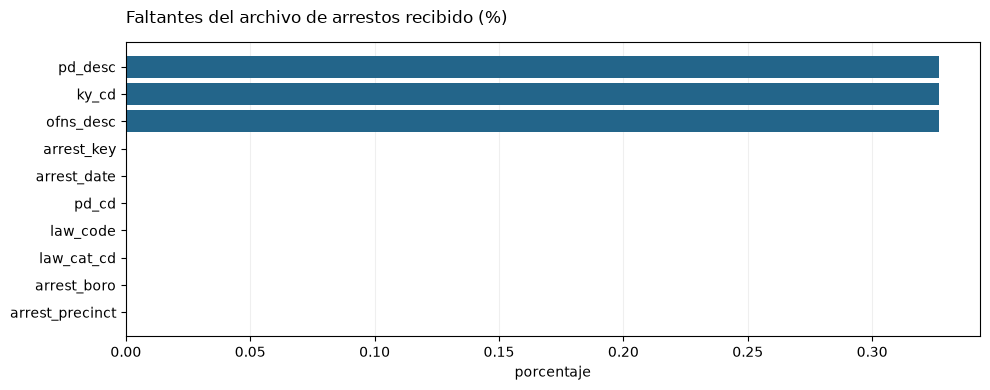

In [3]:
reporte = p.calidad(df_crudo)
p.tabla(reporte, 100)
p.guardar_json("01_calidad_arrestos.json", reporte)
p.barras(sorted(
    reporte, 
    key=lambda r: r["faltantes"], 
    reverse=True
)[:10],
         
         "columna", 
         "porcentaje", 
         "Faltantes del archivo de arrestos recibido (%)", 
         "calidad_arrestos.png"
        )

## 4. Cobertura temporal

La fecha se convierte de forma tolerante, con el objetivo de que los errores se conserven como nulos y se cuenten. Esta tabla determina si la fuente permite el diagnóstico histórico para el año objetivo.

In [4]:
base = df_crudo.withColumn("fecha", p.fecha("arrest_date"))
anios = p.cobertura(base)
p.tabla(anios)
p.guardar_json("02_cobertura_arrestos.json", anios)
base.select(
    F.min("fecha").alias("primera_fecha"), 
            F.max("fecha").alias("ultima_fecha"),
            F.sum(F.col("fecha").isNull().cast("int")).alias("fechas_no_interpretables")).show()

arrestos_2018 = base.filter(F.year("fecha") == ANIO)
num_2018 = arrestos_2018.count()
print("Registros del año objetivo:", num_2018)
if num_2018 == 0:
    display(Markdown("No hay cobertura para el 2018, por lo que no se generarán tasas ni conclusiones históricas de arrestos con este archivo."))

anio,count
2018,917


+-------------+------------+------------------------+
|primera_fecha|ultima_fecha|fechas_no_interpretables|
+-------------+------------+------------------------+
|   2018-12-01|  2018-12-31|                       0|
+-------------+------------+------------------------+

Registros del año objetivo: 917


## 5. Limpieza de dataset y trazabilidad

Se eliminan duplicados exactos. Si una misma clave tiene filas diferentes, se excluyen todas esas filas del resumen hasta investigar el conflicto. Un distrito desconocido permanece sin asignación y se reporta; no se deduce a partir de otro campo.

In [5]:
limpio, auditoria = p.depurar_identificador(arrestos_2018, ["arrest_key"])
limpio = (limpio.withColumn("codigo_boro", F.upper(p.texto("arrest_boro")))
          .withColumn("borough", p.mapa("codigo_boro", p.BORO_ARRESTOS))
          .withColumn("anio", F.year("fecha")))
auditoria["sin_distrito_interpretable"] = limpio.filter(F.col("borough").isNull()).count()
p.tabla([auditoria])
ruta = p.guardar_json("01_limpieza_arrestos.json", auditoria)
print("Reporte guardado en:", ruta)

filas_originales,duplicados_exactos,filas_sin_clave,filas_con_clave_conflictiva_excluidas,filas_conservadas,sin_distrito_interpretable
917,0,0,0,917,0


Reporte guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/01_limpieza_arrestos.json


## 6. Exploración demográfica

Esta distribución describe eventos registrados por grupo de edad.

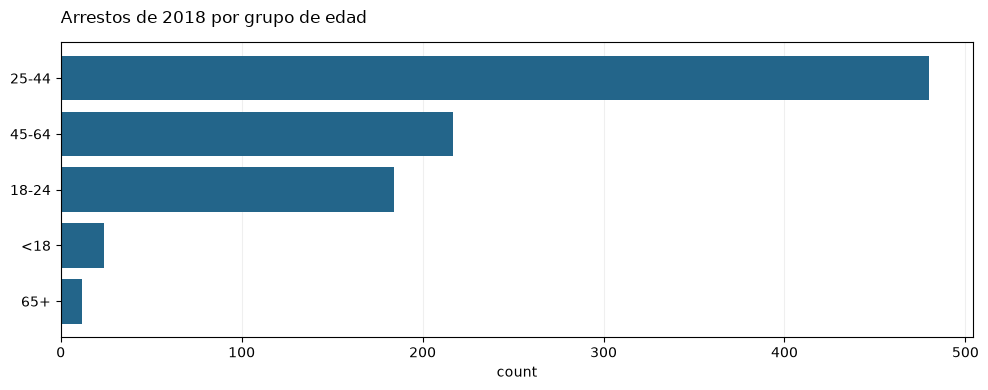

In [6]:
# Este bloque explora los datos del dataset filtrado y agrupa los datos por edades.

edad = p.filas(limpio.groupBy("age_group").count().orderBy(F.desc("count")))
p.barras(edad, "age_group", "count", "Arrestos de 2018 por grupo de edad", "01_edades_arrestos_2018.png")

## 7. Salida para el cuaderno #4

Se guarda una tabla pequeña por distrito y año. El estado de cobertura acompaña los datos y evita interpretar una tabla vacía como cero eventos.

anio,borough,arrestos
2018,Brooklyn,237
2018,Bronx,215
2018,Manhattan,209
2018,Queens,206
2018,Staten Island,50


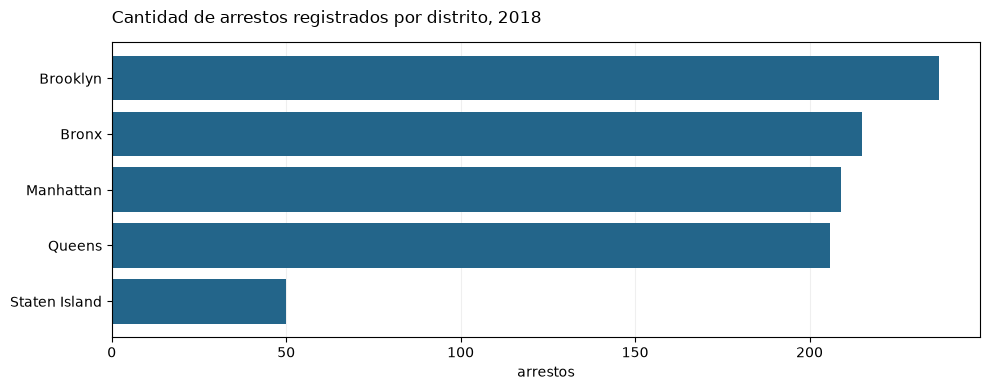

Guardado en: /opt/cluster/Proyecto/Entrega_1/resultados/arrestos_resumen.json


In [7]:
# Contar arrestos por año y distrito.
resumen = (
    limpio
    .filter(F.col("borough").isNotNull())
    .groupBy("anio", "borough")
    .agg(F.count("*").alias("arrestos"))
)

# Ordenar los distritos de mayor a menor cantidad.
resumen_ordenado = resumen.orderBy(F.desc("arrestos"))

# Convertir únicamente el resumen pequeño para mostrarlo.
datos_grafica = p.filas(resumen_ordenado)

p.tabla(datos_grafica)

# Mostrar la gráfica y guardarla como PNG.
p.barras(
    datos_grafica,
    "borough",
    "arrestos",
    f"Cantidad de arrestos registrados por distrito, {ANIO}",
    "01_arrestos_por_distrito.png"
)

# Guardar el resumen para el cuaderno de integración.
estado = "disponible" if num_2018 else "sin_datos_2018"

ruta = p.exportar_resumen(
    resumen,
    "arrestos_resumen.json",
    "Arrestos_NY.csv",
    estado,
    {
        "cobertura": anios,
        "auditoria": auditoria,
        "unidad": "eventos de arresto"
    }
)

print("Guardado en:", ruta)

## Cierre

Los JSON y PNG quedan guardados.

In [8]:
# Cierra sesión y limpia cache

spark.catalog.clearCache()
spark.stop()